# 03 · Modelagem hedônica

O notebook 02 encontrou que **a composição** do crime (a fração dele que é violenta) tem correlação forte e negativa com o preço real do metro quadrado, enquanto a **contagem** de crime não tem correlação nenhuma. Falta responder duas coisas que correlação não responde:

1. Esse sinal sobrevive depois de descontar as características físicas do imóvel? Ou bairros com menos violência simplesmente têm apartamentos maiores e mais novos, e o crime vem de carona?
2. Quanto do sinal é sobre crime, e quanto é só "em que parte da cidade fica"?

Um **modelo hedônico** responde a primeira: prevê o preço a partir de área, tipo, padrão e idade, e então pergunta se o crime do bairro ainda acrescenta informação. A segunda é respondida pela terceira linha da ablação na seção 6, que mede o quanto a identidade do bairro — pura localização, sem hipótese sobre o porquê — conseguiria explicar.

A evidência decisiva deste notebook não é o R² nem o coeficiente isolado, é a **ablação**: treinar o mesmo modelo três vezes, mudando só o conjunto de variáveis, e comparar no conjunto de teste.

### Fluxo treino / validação / teste

| partição | % | para que serve |
|---|---|---|
| treino | 70% | ajustar os parâmetros dos modelos |
| validação | 15% | **escolher** entre os modelos |
| teste | 15% | medir o desempenho final, uma única vez |

A validação existe para que a escolha do modelo não contamine a estimativa final. Se escolhêssemos pelo teste, o número reportado seria otimista — teríamos usado o teste para tomar uma decisão.

Os preços já chegam aqui **deflacionados pelo IPCA oficial do IBGE**, em reais constantes, conforme feito no notebook 02. Isso importa para o modelo: em termos nominais o metro quadrado de São Paulo subiu 22,6% no período, mas em termos reais caiu 1,2% — sem a deflação, a variável `ano` absorveria uma valorização que não existiu.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
CACHE = RAIZ / "data" / "SP" / "cache"

modelagem = pd.read_parquet(CACHE / "base_modelagem.parquet")
bairros = pd.read_parquet(CACHE / "bairros.parquet")
MES_REFERENCIA = (CACHE / "mes_referencia.txt").read_text(encoding="utf-8").strip()

AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SUPERFICIE, TINTA, TINTA2, MUDO, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
DIVERGENTE = LinearSegmentedColormap.from_list("div", [AZUL, "#f0efec", "#e34948"])

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelcolor": TINTA2, "axes.labelsize": 10,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 8,
})

print(f"{len(modelagem):,} transações · {bairros.shape[0]} bairros")
print(f"preços em reais constantes de {MES_REFERENCIA}")

312,322 transações · 430 bairros
preços em reais constantes de 2026-08


## 1 · Alvo e variáveis

O alvo é **log do R$/m²**. Duas razões: a distribuição de preço tem cauda longa (visto na seção 3 do notebook 02) e em log fica quase simétrica, o que é o que a regressão linear assume; e o coeficiente passa a ser lido direto como variação percentual.

Sobre as variáveis de crime, uma decisão importante: entre as quatro medidas construídas no notebook 02, apenas **duas** entram no modelo — o nível (`log` dos crimes violentos) e a composição (`% de crimes que são violentos`). A célula seguinte mostra o motivo: contagem total e contagem violenta são quase a mesma variável, e colocar as duas juntas numa regressão espalha o efeito entre elas de forma arbitrária, tornando cada coeficiente individual ilegível. O nível e a composição, ao contrário, carregam informações diferentes.

In [2]:
bairros[["log_crimes_total", "log_violentos", "share_violento", "log_violentos_por_1k"]].corr().round(2)

,log_crimes_total,log_violentos,share_violento,log_violentos_por_1k
log_crimes_total,1.00,0.98,-0.28,0.57
log_violentos,0.98,1.00,-0.10,0.63
share_violento,-0.28,-0.10,1.00,0.20
log_violentos_por_1k,0.57,0.63,0.20,1.00


In [3]:
NUMERICAS_IMOVEL = ["area_construida", "area_terreno", "testada", "fracao_ideal", "idade", "ano"]
CATEGORICAS_IMOVEL = ["uso_desc", "padrao_desc"]
CRIME = ["log_violentos", "share_violento"]

dados = modelagem.copy()
dados["log_violentos"] = np.log10(1 + dados["violentos"])
dados[CATEGORICAS_IMOVEL] = dados[CATEGORICAS_IMOVEL].astype(str)
dados["alvo"] = np.log(dados["preco_m2"])

dados = dados[NUMERICAS_IMOVEL + CATEGORICAS_IMOVEL + CRIME + ["alvo", "bairro"]]
dados.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
area_construida,312322.0,133.31,101.71,2.00,77.00,107.00,157.00,6425.00
area_terreno,312322.0,5168.78,15115.54,24.00,616.00,1656.00,4338.00,233403.00
testada,312322.0,50.45,78.93,0.00,10.00,30.00,60.00,1158.14
fracao_ideal,312322.0,0.20,0.38,0.00,0.00,0.01,0.05,1.00
idade,312322.0,25.96,19.93,0.00,8.00,22.00,43.00,107.00
ano,312322.0,2023.96,1.35,2022.00,2023.00,2024.00,2025.00,2026.00
log_violentos,312322.0,2.61,0.72,0.76,1.95,2.97,3.19,3.65
share_violento,312322.0,0.33,0.10,0.10,0.25,0.31,0.39,0.67
alvo,312322.0,8.49,0.57,3.62,8.21,8.53,8.83,9.83


## 2 · Divisão treino / validação / teste

Divisão aleatória 70/15/15. Aleatória, e não temporal, porque a hipótese é **transversal** — compara bairros entre si no mesmo período. Um corte temporal mediria algo diferente: a capacidade de prever preços futuros, onde a inflação imobiliária se confunde com o efeito do crime.

`random_state` fixo para que a divisão seja a mesma a cada execução — sem isso, a comparação entre modelos muda de resultado a cada rodada.

In [4]:
treino, resto = train_test_split(dados, test_size=0.30, random_state=42)
validacao, teste = train_test_split(resto, test_size=0.50, random_state=42)

PARTICOES = {"treino": treino, "validação": validacao, "teste": teste}

pd.DataFrame(
    [
        {
            "partição": nome,
            "transações": len(parte),
            "% do total": len(parte) / len(dados),
            "alvo médio": parte["alvo"].mean(),
            "R$/m² mediano": np.exp(parte["alvo"].median()),
        }
        for nome, parte in PARTICOES.items()
    ]
).style.format({
    "transações": "{:,.0f}", "% do total": "{:.0%}",
    "alvo médio": "{:.3f}", "R$/m² mediano": "R$ {:,.0f}",
}).hide(axis="index")

partição,transações,% do total,alvo médio,R$/m² mediano
treino,"218,625",70%,8.489,"R$ 5,058"
validação,"46,848",15%,8.485,"R$ 5,045"
teste,"46,849",15%,8.488,"R$ 5,067"


As três partições têm alvo médio praticamente idêntico, que é o que se espera de uma divisão aleatória de uma base grande. Se divergissem, a comparação entre partições estaria medindo diferença de amostra, não de modelo.

## 3 · Pipeline

Todo o pré-processamento vive dentro de um `Pipeline` do scikit-learn, nunca aplicado à mão antes do split. Esse detalhe evita a forma mais comum de vazamento de dados: se a mediana do imputador ou a média do `StandardScaler` fossem calculadas na base inteira, o modelo já teria visto informação do teste antes de ser avaliado. Dentro do pipeline, esses parâmetros são aprendidos só no `fit`, isto é, só no treino.

**Duas codificações para variáveis categóricas**, por um motivo prático:

- `uso` e `padrão` têm poucas categorias → `OneHotEncoder`, uma coluna por categoria.
- `bairro` tem 430 categorias → one-hot geraria 430 colunas quase todas zero, e o `HistGradientBoosting` não aceita matriz esparsa. Usa-se `TargetEncoder`, que substitui cada bairro pela média do alvo naquele bairro, calculada com validação cruzada interna justamente para não vazar o alvo.

Dois modelos, de propósito diferente:

- **Ridge** — linear e regularizado. Interessa pelo **coeficiente**: com as variáveis padronizadas, ele diz quanto o preço varia por desvio-padrão de crime, com sinal.
- **HistGradientBoosting** — árvores impulsionadas. Interessa pelo **desempenho**: captura não linearidade e interação sem que seja preciso especificá-las.

In [5]:
def monta_preprocessador(numericas, categoricas, alta_cardinalidade=()):
    passos = [
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50, sparse_output=False), categoricas),
    ]
    if alta_cardinalidade:
        passos.append(("alta", TargetEncoder(target_type="continuous"), list(alta_cardinalidade)))
    return ColumnTransformer(passos)


def monta_modelos(numericas, categoricas, alta_cardinalidade=()):
    preprocessador = monta_preprocessador(numericas, categoricas, alta_cardinalidade)
    return {
        "Ridge": Pipeline([("prep", preprocessador), ("reg", Ridge(alpha=1.0))]),
        "HistGradientBoosting": Pipeline([
            ("prep", preprocessador),
            ("reg", HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, random_state=42)),
        ]),
    }


def metricas(modelo, parte, colunas):
    previsto = modelo.predict(parte[colunas])
    real = parte["alvo"]
    return {
        "RMSE (log)": root_mean_squared_error(real, previsto),
        "MAE (log)": mean_absolute_error(real, previsto),
        "R²": r2_score(real, previsto),
        "erro mediano": np.median(np.abs(np.expm1(previsto - real))),
    }


FORMATO = {"RMSE (log)": "{:.4f}", "MAE (log)": "{:.4f}", "R²": "{:.4f}", "erro mediano": "{:.1%}"}

TODAS = NUMERICAS_IMOVEL + CATEGORICAS_IMOVEL + CRIME
SEM_CRIME = NUMERICAS_IMOVEL + CATEGORICAS_IMOVEL

## 4 · Treino e escolha do modelo pela validação

`erro mediano` é a métrica para interpretar: como o alvo está em log, `exp(previsto − real) − 1` é o erro relativo da previsão. A mediana desse valor diz, em porcentagem, o quanto o modelo erra numa transação típica.

In [6]:
modelos = monta_modelos(NUMERICAS_IMOVEL + CRIME, CATEGORICAS_IMOVEL)
for modelo in modelos.values():
    modelo.fit(treino[TODAS], treino["alvo"])

comparacao = pd.DataFrame(
    [
        {"modelo": nome, "partição": particao, **metricas(modelo, parte, TODAS)}
        for nome, modelo in modelos.items()
        for particao, parte in [("treino", treino), ("validação", validacao)]
    ]
).set_index(["modelo", "partição"])

comparacao.style.format(FORMATO)

In [7]:
r2_validacao = comparacao.xs("validação", level="partição")["R²"]
vencedor = r2_validacao.idxmax()
print(f"Escolhido pela validação: {vencedor} (R² = {r2_validacao.max():.4f})")

Escolhido pela validação: HistGradientBoosting (R² = 0.4210)


## 5 · Desempenho final no teste

O teste é avaliado uma única vez, com o modelo já escolhido.

In [8]:
modelo_final = modelos[vencedor]

pd.DataFrame(
    [{"partição": nome, **metricas(modelo_final, parte, TODAS)} for nome, parte in PARTICOES.items()]
).set_index("partição").style.format(FORMATO)

,RMSE (log),MAE (log),R²,erro mediano
partição,,,,
treino,0.4153,0.2574,0.4590,17.5%
validação,0.4319,0.2641,0.4210,17.8%
teste,0.4333,0.2647,0.4156,17.8%


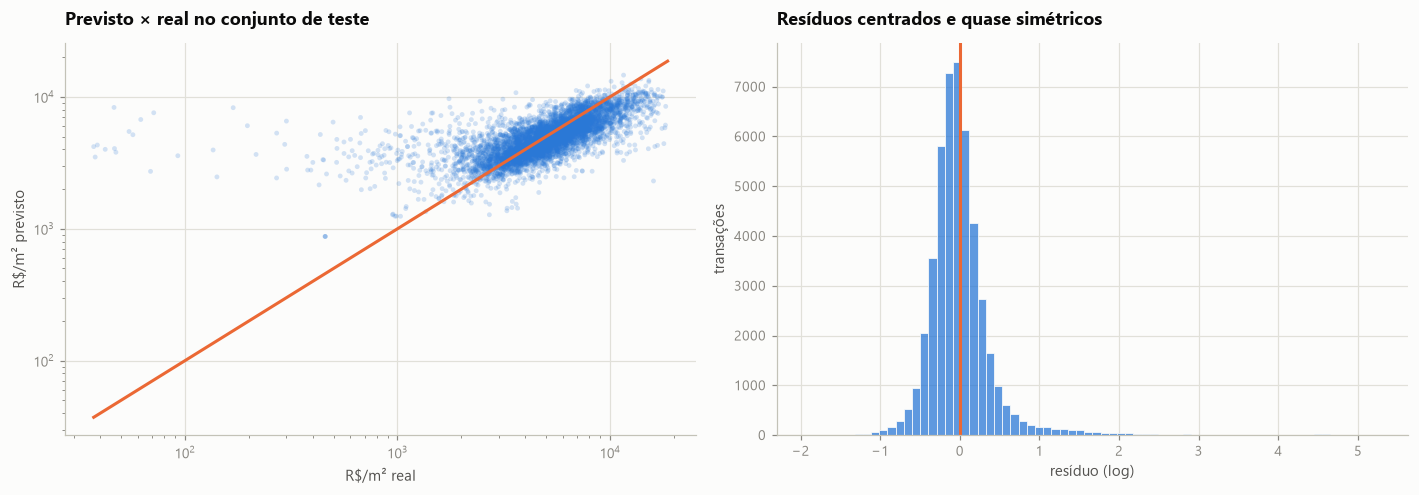

In [9]:
previsto = modelo_final.predict(teste[TODAS])
amostra = np.random.default_rng(42).choice(len(teste), size=min(6000, len(teste)), replace=False)

fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.6))

esq.scatter(np.exp(teste["alvo"].to_numpy()[amostra]), np.exp(previsto[amostra]),
            s=10, alpha=0.2, color=AZUL, edgecolor="none")
limites = np.exp([teste["alvo"].min(), teste["alvo"].max()])
esq.plot(limites, limites, color=LARANJA, linewidth=2)
esq.set(title="Previsto × real no conjunto de teste", xlabel="R$/m² real", ylabel="R$/m² previsto",
        xscale="log", yscale="log")

sns.histplot(previsto - teste["alvo"], bins=70, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.5, ax=drt)
drt.axvline(0, color=LARANJA, linewidth=2)
drt.set(title="Resíduos centrados e quase simétricos", xlabel="resíduo (log)", ylabel="transações")

plt.tight_layout()

## 6 · Ablação — o crime agrega informação?

A prova central. O mesmo pipeline, o mesmo split, as mesmas sementes; muda **só** o conjunto de variáveis. Três modelos:

1. **só atributos do imóvel** — área, terreno, testada, fração ideal, idade, ano, uso, padrão. É o piso.
2. **imóvel + crime** — acrescenta as duas variáveis de crime do bairro. Se o R² de teste subir, o crime carrega informação de preço que os atributos físicos não carregam.
3. **imóvel + identidade do bairro** — acrescenta os 249 bairros como variável categórica, em vez do crime. É o **teto de localização**: o máximo que se pode extrair de "onde fica", sem nenhuma hipótese sobre o porquê.

O terceiro modelo existe para responder a objeção mais séria a este notebook: *as duas variáveis de crime não são só um jeito disfarçado de dizer em que parte da cidade o imóvel está?* Em parte são — crime correlaciona com renda, infraestrutura e tudo que distingue um bairro de outro. A comparação entre os modelos 2 e 3 quantifica quanto. Se o modelo 2 chega perto do 3, duas variáveis de crime estão capturando quase toda a informação de localização relevante para preço. Se fica muito abaixo, o crime captura só uma fatia dela.

De qualquer forma, o ganho do modelo 2 sobre o 1 continua valendo como resultado — ele mostra que crime prevê preço. O que o modelo 3 impede é a interpretação exagerada de que esse ganho se deve ao crime *em si*.

In [10]:
CONJUNTOS = {
    "1 · só atributos do imóvel": (SEM_CRIME, NUMERICAS_IMOVEL, ()),
    "2 · imóvel + crime": (TODAS, NUMERICAS_IMOVEL + CRIME, ()),
    "3 · imóvel + identidade do bairro": (SEM_CRIME + ["bairro"], NUMERICAS_IMOVEL, ("bairro",)),
}

ablacao = []
for rotulo, (colunas, numericas, alta) in CONJUNTOS.items():
    modelo = monta_modelos(numericas, CATEGORICAS_IMOVEL, alta)[vencedor]
    modelo.fit(treino[colunas], treino["alvo"])
    ablacao.append({"conjunto de variáveis": rotulo, **metricas(modelo, teste, colunas)})

ablacao = pd.DataFrame(ablacao).set_index("conjunto de variáveis")
r2 = ablacao["R²"]
ganho = r2.iloc[1] - r2.iloc[0]
teto = r2.iloc[2] - r2.iloc[0]
reducao = 1 - ablacao["RMSE (log)"].iloc[1] / ablacao["RMSE (log)"].iloc[0]

print(f"Ganho de R² das 2 variáveis de crime ........ {ganho:+.4f}")
print(f"Ganho de R² da identidade do bairro (teto) .. {teto:+.4f}")
print(f"O crime captura ............................. {ganho / teto:.0%} do teto de localização")
print(f"Redução do RMSE no teste pelo crime ......... {reducao:+.2%}")
ablacao.style.format(FORMATO)

Ganho de R² das 2 variáveis de crime ........ +0.1137
Ganho de R² da identidade do bairro (teto) .. +0.1179
O crime captura ............................. 96% do teto de localização
Redução do RMSE no teste pelo crime ......... +8.50%


,RMSE (log),MAE (log),R²,erro mediano
conjunto de variáveis,,,,
1 · só atributos do imóvel,0.4736,0.3062,0.3020,21.0%
2 · imóvel + crime,0.4333,0.2647,0.4156,17.8%
3 · imóvel + identidade do bairro,0.4317,0.2625,0.4199,17.6%


## 7 · Interpretação dos coeficientes

O Ridge é reajustado aqui mesmo quando não foi o vencedor, porque é dele que sai a leitura com sinal. Como as numéricas passaram pelo `StandardScaler`, cada coeficiente é a variação em log do preço por **um desvio-padrão** da variável. Multiplicado por 100, aproxima a variação percentual.

A hipótese prevê coeficiente **negativo** em `log_violentos`.

,coeficiente
num__log_violentos,0.0035
num__share_violento,-0.1435


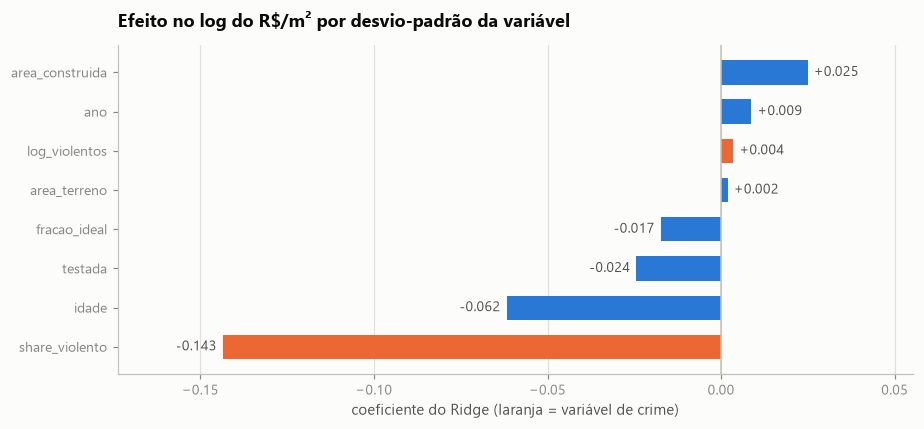

In [11]:
ridge = monta_modelos(NUMERICAS_IMOVEL + CRIME, CATEGORICAS_IMOVEL)["Ridge"]
ridge.fit(treino[TODAS], treino["alvo"])

coeficientes = pd.Series(
    ridge["reg"].coef_, index=ridge["prep"].get_feature_names_out()
).rename("coeficiente")

numericos = coeficientes[coeficientes.index.str.startswith("num__")].sort_values()
numericos.index = numericos.index.str.removeprefix("num__")

cores = [LARANJA if nome in CRIME else AZUL for nome in numericos.index]

fig, eixo = plt.subplots(figsize=(8.5, 4))
barras = eixo.barh(numericos.index, numericos.values, color=cores, height=0.62)
eixo.bar_label(barras, fmt="%+.3f", padding=4, color=TINTA2, fontsize=9)
eixo.axvline(0, color="#c3c2b7", linewidth=1)
eixo.set(title="Efeito no log do R$/m² por desvio-padrão da variável",
         xlabel="coeficiente do Ridge (laranja = variável de crime)")
eixo.grid(axis="y", visible=False)
eixo.margins(x=0.18)
plt.tight_layout()

coeficientes.filter(items=[f"num__{c}" for c in CRIME]).to_frame().round(4)

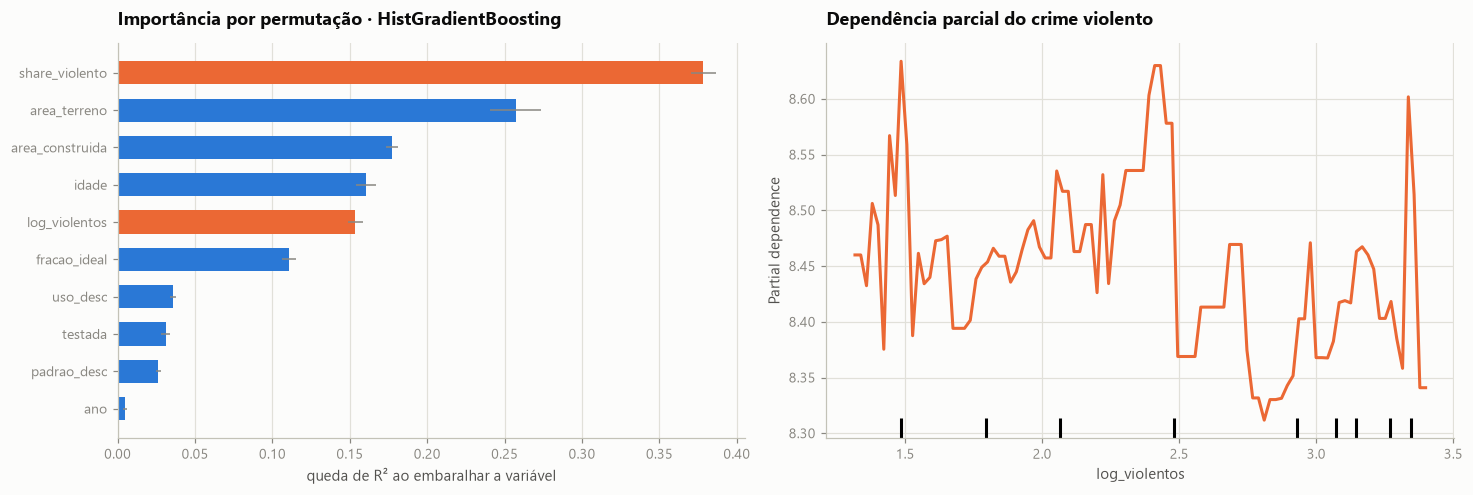

In [12]:
sub = validacao.sample(min(4000, len(validacao)), random_state=42)

importancia = permutation_importance(
    modelo_final, sub[TODAS], sub["alvo"], n_repeats=5, random_state=42, scoring="r2"
)
ordem = pd.Series(importancia.importances_mean, index=TODAS).sort_values()
erros = pd.Series(importancia.importances_std, index=TODAS)[ordem.index]

fig, (esq, drt) = plt.subplots(1, 2, figsize=(13.5, 4.6))

esq.barh(ordem.index, ordem.to_numpy(), xerr=erros.to_numpy(), height=0.62,
         color=[LARANJA if n in CRIME else AZUL for n in ordem.index],
         error_kw={"ecolor": MUDO, "elinewidth": 1})
esq.set(title=f"Importância por permutação · {vencedor}", xlabel="queda de R² ao embaralhar a variável")
esq.grid(axis="y", visible=False)

PartialDependenceDisplay.from_estimator(
    modelo_final, sub[TODAS], features=["log_violentos"], ax=drt,
    line_kw={"color": LARANJA, "linewidth": 2},
)
drt.set(title="Dependência parcial do crime violento",
        xlabel="log₁₀(1 + crimes violentos por ano no bairro)", ylabel="log do R$/m² previsto")

plt.tight_layout()

A dependência parcial mostra a forma do efeito: mantendo tudo o mais constante, como o preço previsto se move conforme o crime do bairro cresce. É a leitura mais honesta do modelo de árvores, que não tem coeficiente.

## 8 · Teste estatístico formal

Os modelos acima dizem se o crime **prevê** preço. Esta seção dá a resposta estatística clássica: o coeficiente é distinguível de zero?

A regressão é no nível de **bairro**, não de transação, e isso é deliberado. Crime é uma característica do bairro: usar 300 mil transações repetiria a mesma informação de crime milhares de vezes e produziria um intervalo de confiança artificialmente estreito. Com um bairro por linha, o erro-padrão reflete a quantidade real de informação independente disponível.

Controles: tamanho do imóvel, idade e volume de transações — este último como aproximação do porte do bairro.

In [13]:
ols = smf.ols(
    "np.log(preco_m2_mediano) ~ log_violentos + share_violento"
    " + np.log(area_mediana) + idade_mediana + np.log(n_transacoes)",
    data=bairros,
).fit()

print(ols.summary().tables[1])
print(f"\nR² = {ols.rsquared:.3f} · {int(ols.nobs)} bairros")

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.9107      0.198     34.869      0.000       6.521       7.300
log_violentos           -0.0325      0.020     -1.591      0.112      -0.073       0.008
share_violento          -0.9122      0.109     -8.344      0.000      -1.127      -0.697
np.log(area_mediana)     0.3110      0.037      8.330      0.000       0.238       0.384
idade_mediana            0.0017      0.001      1.676      0.094      -0.000       0.004
np.log(n_transacoes)     0.0658      0.011      5.939      0.000       0.044       0.088

R² = 0.411 · 430 bairros


,coeficiente,"IC 2,5%","IC 97,5%",p-valor
log_violentos,-0.0325,-0.0727,0.0077,0.1124
share_violento,-0.9122,-1.1271,-0.6973,0.0000


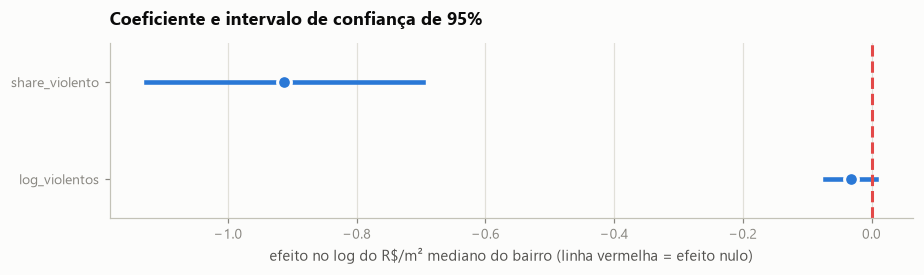

In [14]:
intervalos = ols.conf_int().loc[["log_violentos", "share_violento"]]
intervalos.columns = ["IC 2,5%", "IC 97,5%"]
intervalos["coeficiente"] = ols.params[intervalos.index]
intervalos["p-valor"] = ols.pvalues[intervalos.index]

fig, eixo = plt.subplots(figsize=(8.5, 2.6))
for altura, (nome, linha) in enumerate(intervalos.iterrows()):
    eixo.plot([linha["IC 2,5%"], linha["IC 97,5%"]], [altura, altura], color=AZUL, linewidth=3)
    eixo.plot(linha["coeficiente"], altura, "o", color=AZUL, markersize=9,
              markeredgecolor=SUPERFICIE, markeredgewidth=2)

eixo.axvline(0, color="#e34948", linewidth=2, linestyle="--")
eixo.set(yticks=range(len(intervalos)), yticklabels=intervalos.index,
         title="Coeficiente e intervalo de confiança de 95%",
         xlabel="efeito no log do R$/m² mediano do bairro (linha vermelha = efeito nulo)")
eixo.grid(axis="y", visible=False)
eixo.margins(y=0.4)
plt.tight_layout()

intervalos[["coeficiente", "IC 2,5%", "IC 97,5%", "p-valor"]].round(4)

Um intervalo de confiança que **não cruza a linha vermelha** significa que o efeito é estatisticamente distinguível de zero no nível de 95%. O sinal do coeficiente é o que responde à hipótese: negativo confirma que mais crime acompanha preço mais baixo, mantidos os controles.

In [15]:
efeito_10pp = np.exp(ols.params["share_violento"] * 0.10) - 1
efeito_dobro = np.exp(ols.params["log_violentos"] * np.log10(2)) - 1

print(f"Modelo escolhido na validação ................ {vencedor}")
print(f"R² no teste (imóvel + crime) ................. {r2.iloc[1]:.4f}")
print(f"Erro mediano no teste ........................ {ablacao['erro mediano'].iloc[1]:.1%}")
print(f"Ganho de R² das variáveis de crime ........... {ganho:+.4f}")
print(f"  ... sobre o teto de localização ............ {ganho / teto:.0%}")
print()
print("OLS no nível bairro — as duas variáveis de crime:")
for nome in CRIME:
    print(f"  {nome:<16} {ols.params[nome]:+.4f}  (p = {ols.pvalues[nome]:.1e})")
print()
print("Efeito prático, mantidos os controles:")
print(f"  +10 pontos percentuais no % de crimes violentos .. {efeito_10pp:+.1%} no R$/m² do bairro")
print(f"  dobrar a contagem de crimes violentos ............ {efeito_dobro:+.1%} (não significativo)")

Modelo escolhido na validação ................ HistGradientBoosting
R² no teste (imóvel + crime) ................. 0.4156
Erro mediano no teste ........................ 17.8%
Ganho de R² das variáveis de crime ........... +0.1137
  ... sobre o teto de localização ............ 96%

OLS no nível bairro — as duas variáveis de crime:
  log_violentos    -0.0325  (p = 1.1e-01)
  share_violento   -0.9122  (p = 1.0e-15)

Efeito prático, mantidos os controles:
  +10 pontos percentuais no % de crimes violentos .. -8.7% no R$/m² do bairro
  dobrar a contagem de crimes violentos ............ -1.0% (não significativo)


## 9 · Conclusão

### A hipótese

> *Crime e preço de imóvel têm correlação negativa: quanto maior o crime, menor o preço.*

**Confirmada, com uma correção importante na formulação.** Não é a *quantidade* de crime que se precifica — é a *violência* dele.

| evidência | resultado |
|---|---|
| Correlação (430 bairros) — contagem de crimes violentos | ρ = +0,04 · **nenhuma relação** |
| Correlação — % dos crimes que são violentos | ρ = **−0,55** (p ≈ 10⁻³⁵) |
| R$/m² real do quintil menos violento → mais violento | R$ 5.019 → R$ 3.480 (**−31%**) |
| Ganho de R² no teste ao incluir crime | **+0,114** (0,302 → 0,416) |
| Redução do RMSE no teste | **−8,5%** |
| OLS: coeficiente de `share_violento` | **−0,912** (p ≈ 10⁻¹⁵), IC 95% [−1,13; −0,70] |
| OLS: coeficiente de `log_violentos` | −0,033 (p = 0,11) · não significativo |
| Efeito de +10 p.p. no % de crimes violentos | **−8,7%** no R$/m² do bairro |

Os três níveis de evidência — correlação, poder preditivo e significância estatística — apontam na mesma direção e na mesma variável. O modelo erra 17,8% numa transação típica, o que é razoável para preço de imóvel com apenas atributos cadastrais e sem nenhuma informação sobre o estado de conservação, a vista, o andar ou a reforma.

### A ressalva que o número 96% impõe

A ablação mostrou que as **duas** variáveis de crime capturam **96% do ganho** que a identidade dos 430 bairros capturaria. Isso é uma faca de dois fios:

- **Lado impressionante:** dois números resumem quase toda a informação de localização que importa para preço. Como variável de engenharia de atributos, a composição criminal do bairro é extraordinariamente eficiente.
- **Lado cauteloso, e é o que importa para a interpretação:** se o crime carrega quase tudo que "qual bairro" carrega, então ele está em grande parte **funcionando como marcador de localização** — e localização, em São Paulo, significa renda, infraestrutura, transporte, escolaridade e história urbana. O ganho de R² **não** pode ser lido como "o efeito causal do crime sobre o preço".

Em outras palavras: o resultado é solidamente **descritivo e preditivo**, não causal. Sabemos que bairros com crime proporcionalmente mais violento têm metro quadrado mais barato, com força e consistência; e sabemos que essa informação prevê preço. Não sabemos quanto do desconto é medo da violência e quanto é tudo o mais que anda junto com ela.

### O que faltou, e o que destravaria

| limitação | o que resolveria |
|---|---|
| Sem taxa de crime por habitante — só por transação | População por setor censitário **de São Paulo** (a do repositório é do Rio) |
| Sem controle de renda, o confundidor mais provável | Renda por setor censitário do Censo 2022 |
| Sem argumento causal | Janela temporal mais longa, para observar preço **depois** de mudança no nível de crime do bairro |
| Geografia por CEP e nome de rua, não por coordenada do imóvel | Geocodificação do endereço do ITBI |

A primeira linha é a mais importante. Com população por setor censitário, `share_violento` poderia ser substituído por uma taxa de homicídio e roubo por 100 mil habitantes — a medida que a literatura de economia urbana usa, e que separa de verdade exposição de risco. Com renda no modelo, a pergunta deixaria de ser "crime prevê preço?" e passaria a ser "crime prevê preço **a renda constante?**", que é a pergunta que realmente interessa.